# On-device continual triage with **online SDFT** (LFM2.5-230M)

**Online SDFT** = self-distillation fine-tuning run *online*: a phone-class 230M
model learns your **drifting** notification-triage policy from **implicit feedback**
(open now / let it wait / never opened) — **no gold labels** — with one
`batch_size=1` LoRA update per item. The policy lives in a **~1.4 MB adapter**, so
serving is a bare ~90-token prompt (no growing ICL cheat-sheet, no RAG index).

### What this notebook shows
1. Load the seeded 3-regime inbox stream (`weekday → on-call → off-hours`).
2. Grade causal **ZS / ICL / RAG** baselines (held-out accuracy + accumulated regret).
3. Run the **online SDFT** loop (guess → feedback → update → probe guardrail).
4. Plot the three-panel figure: whole-week accuracy vs token bill, current-regime
   tracking, accumulated regret — then spot-check one social notification.

Expect **Online-SDFT** to track each regime while it is live and finish with
**fewer stream mistakes** than frozen ICL/RAG (exact numbers vary a little by
GPU/driver; the qualitative gap is the point).

### How to run
1. **Runtime → Change runtime type → GPU** (free Colab **T4** is enough; ~2–4 min
   end-to-end after the first model download).
2. **Runtime → Run all** (or run cells top → bottom). Do not skip earlier cells —
   later sections reuse `stream`, `base`, `arms`, and the trained adapter.

The base model ([LFM2.5-230M](https://huggingface.co/LiquidAI/LFM2.5-230M)) is
**not gated**. An optional Hugging Face token only helps with Hub rate limits
(see Setup). Paper: [Shenfeld et al., 2026](https://self-distillation.github.io/SDFT)
([arXiv](https://arxiv.org/abs/2601.19897)). Full scripts:
[Online-SDFT-Demo](https://github.com/lin826/Online-SDFT-Demo).


## Setup

**Runtime → GPU** (T4 is plenty). This cell installs the deps used below and removes a stale `torchao` that can break Colab's `transformers` stack.

Optional: if Hub downloads throttle, add a Colab secret named `HF_TOKEN` (or set the env var). The model itself does **not** require auth.


In [1]:
%pip install -q "transformers>=4.54" "peft>=0.15" "accelerate>=0.33" "matplotlib>=3.8"
%pip uninstall -y -q torchao

# Optional Hub auth (rate limits only — LFM2.5-230M is not gated)
import os
try:
    from google.colab import userdata
    _tok = userdata.get("HF_TOKEN")
    if _tok:
        os.environ["HF_TOKEN"] = _tok
        os.environ["HUGGING_FACE_HUB_TOKEN"] = _tok
except Exception:
    pass

print("setup ok — 3-way / 3-regime online SDFT triage demo")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 885.0/885.0 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 18.2 MB/s eta 0:00:00
setup ok — 3-way / 3-regime online SDFT triage demo


## Fetch the seeded dataset

One `urllib` call replaces ~100 lines of generator code. The repo ships
[`data/inbox_triage.json`](https://github.com/lin826/Online-SDFT-Demo/blob/main/data/inbox_triage.json)
— the 60-item drifting stream, three 12-item held-out eval sets, and config,
every item with its prompt pre-rendered. Labels encode this latent policy
(bold = a drift flip):

| Category        | weekday   | on-call       | off-hours     |
| --------------- | --------- | ------------- | ------------- |
| `mgr_project`   | INTERRUPT | **LATER**     | **ARCHIVE**   |
| `calendar_soon` | INTERRUPT | INTERRUPT     | **LATER**     |
| `teammate_fyi`  | LATER     | **ARCHIVE**   | ARCHIVE       |
| `monitoring`    | ARCHIVE   | **INTERRUPT** | **ARCHIVE**   |
| `promo`         | ARCHIVE   | ARCHIVE       | **LATER**     |
| `social`        | ARCHIVE   | ARCHIVE       | **INTERRUPT** |
| `receipt`       | LATER     | **ARCHIVE**   | **LATER**     |

Blocks are class-balanced under their own policy (10/10/10, 4/4/4, 6/6/6) across
a realistic 50/20/30 week. Items are deliberately bare — two lines, subject +
snippet, no channel field, no role tags — and the vocabulary sets a trap:
`receipt` ("your **payment** succeeded") and `monitoring` ("**payment** latency")
share words but land on different rungs — you must learn the *policy*, not the
keywords. (The generator lives in
[`triage_common.py`](https://github.com/lin826/Online-SDFT-Demo/blob/main/triage_common.py).)


In [2]:
import copy, json, os, random, re, urllib.request
import torch
from peft import LoraConfig, get_peft_model, get_peft_model_state_dict, set_peft_model_state_dict
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "LiquidAI/LFM2.5-230M"
# Same seeded JSON the repo scripts train on (no git clone needed)
DATA_URL = "https://raw.githubusercontent.com/lin826/Online-SDFT-Demo/main/data/inbox_triage.json"

with urllib.request.urlopen(DATA_URL) as fh:
    data = json.load(fh)
cfg = data["config"]
SEED = cfg["seed"]
ACTIONS = tuple(cfg["actions"])         # INTERRUPT / LATER / ARCHIVE
REGIMES = tuple(cfg["regimes"])         # weekday / on-call / off-hours
STREAM_LEN = cfg["stream_len"]
DRIFTS = tuple(cfg["drifts"])           # weekday 1-30 | on-call 31-42 | off-hours 43-60

CHECKPOINTS = (6, 12, 18, 24, 30, 36, 42, 48, 54, 60)
LORA_R, LORA_ALPHA = 8, 16              # sweep winner (sweep_sdft.py) — ~1.4 MB adapter
LORA_TARGET = r".*self_attn\.(q|k|v|out)_proj"
LR, MAX_NEW = 7e-4, 8                   # 1e-3 overshoots on the live stream
# Accuracy-panel k (whole-week mean); swept in run_baselines.py
ICL_K, RAG_K = 12, 6
# Regret-panel k (least stream mistakes); swept separately
ICL_K_REGRET, RAG_K_REGRET = 12, 3
REPLAY, STEPS_PER_ITEM = 16, 8          # regret-primary sweep winners (sweep_sdft.py)

stream = data["stream"]
evals = {int(k): v for k, v in data["evals"].items()}
eval_cur = evals[3]                     # current policy = final regime = off-hours

random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"fetched {len(stream)} stream + {sum(map(len, evals.values()))} eval items; "
      f"seed={SEED}; regimes {REGIMES}")


fetched 60 stream + 36 eval items; regimes ('weekday', 'on-call', 'off-hours')


## Model + pipeline helpers

Device detection, tokenizer/model load (fp16 + SDPA on CUDA), batched greedy
`generate` with KV cache, causal retriever, and the persistent-optimizer
`batch_size=1` updater used by the online loop.


In [3]:
def device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEV = device()
print("device:", DEV)
if DEV == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

def load_tok():
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    t = AutoTokenizer.from_pretrained(MODEL_NAME, token=token)
    if t.pad_token is None:
        t.pad_token = t.eos_token
    t.padding_side = "left"  # left-pad so batched decoder-only generation lines up
    return t

def load_base():
    token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGING_FACE_HUB_TOKEN")
    dt = torch.float16 if DEV == "cuda" else torch.float32
    # SDPA uses Flash/mem-efficient kernels when the stack supports them
    try:
        m = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME, dtype=dt, attn_implementation="sdpa", token=token)
    except (TypeError, ValueError):
        m = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=dt, token=token)
    m = m.to(DEV)
    m.config.use_cache = True
    m.eval()
    return m

def to_dev(enc, model):
    d = next(model.parameters()).device
    return {k: (v.to(d) if torch.is_tensor(v) else v) for k, v in enc.items()}

def demo_msg(it, a):
    return [{"role": "user", "content": it["prompt"]},
            {"role": "assistant", "content": a}]

def build_msgs(it, demos=None):
    m = []
    for d, a in demos or []:
        m += demo_msg(d, a)
    m.append({"role": "user", "content": it["prompt"]})
    return m

ACTION_RE = re.compile(r"\b(INTERRUPT|LATER|ARCHIVE)\b", re.I)

def parse_action(t):
    m = ACTION_RE.search(t or "")
    return m.group(1).upper() if m else "NONE"

def prompt_tokens(tok, msgs):
    txt = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    return len(tok(txt, add_special_tokens=False)["input_ids"])

def accuracy(items, gens):
    return sum(parse_action(g) == it["action"] for it, g in zip(items, gens)) / max(len(items), 1)

@torch.inference_mode()
def generate(model, tok, items, demos_fn, bs=16, max_new=MAX_NEW):
    """Batched greedy decode via HF generate() with left-padding, KV cache, and SDPA."""
    model.eval()
    was_cache = getattr(model.config, "use_cache", True)
    model.config.use_cache = True
    outs = []
    for s in range(0, len(items), bs):
        batch = items[s:s + bs]
        txts = [
            tok.apply_chat_template(demos_fn(it), tokenize=False, add_generation_prompt=True)
            for it in batch
        ]
        enc = to_dev(
            tok(txts, return_tensors="pt", padding=True, add_special_tokens=False), model)
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            do_sample=False,
            use_cache=True,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )
        prompt_len = enc["input_ids"].shape[1]
        outs.extend(
            t.strip()
            for t in tok.batch_decode(out[:, prompt_len:], skip_special_tokens=True)
        )
    model.config.use_cache = was_cache
    return outs

def probe_phases(model, tok, phases=(1, 2, 3), bs=36):
    """One batched generate over several held-out sets (bare prompts), then split."""
    items, slices, start = [], {}, 0
    for p in phases:
        n = len(evals[p])
        slices[p] = (start, start + n)
        items.extend(evals[p])
        start += n
    gens = generate(model, tok, items, lambda x: build_msgs(x), bs=bs)
    return {p: accuracy(evals[p], gens[a:b]) for p, (a, b) in slices.items()}

def retriever(store):
    toks = [set(re.findall(r"\w+", s["prompt"].lower())) for s in store]
    def r(it, k, upto=None):  # upto = only the first `upto` decisions exist yet (causal)
        pool = range(len(store) if upto is None else min(upto, len(store)))
        q = set(re.findall(r"\w+", it["prompt"].lower()))
        order = sorted(pool, key=lambda i: -len(q & toks[i]))
        return [(store[i], store[i]["action"]) for i in order[:k]]
    return r

def phase_of(pos):  # regime of stream position pos; 0 (nothing yet) = upcoming weekday
    return 1 if pos <= DRIFTS[0] else 2 if pos <= DRIFTS[1] else 3

def recent_demos(history, k):  # the k most recent observed decisions, oldest first
    return [(it, it["action"]) for it in history[-k:]]

# persistent-optimizer online updater (Adam momentum across the stream) + grad clipping
def make_updater(model, tok):
    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable, lr=LR)
    eos = tok.eos_token or ""
    dev = next(model.parameters()).device
    def step(rows, steps):
        model.train()
        model.config.use_cache = False
        for k in range(steps):
            r = rows[k % len(rows)]
            ptxt = tok.apply_chat_template(
                [{"role": "user", "content": r["prompt"]}],
                tokenize=False, add_generation_prompt=True)
            ids_p = tok(ptxt, add_special_tokens=False)["input_ids"]
            ids_c = tok(r["target"] + eos, add_special_tokens=False)["input_ids"]
            ids = torch.tensor([ids_p + ids_c], device=dev)
            labels = torch.tensor([[-100] * len(ids_p) + ids_c], device=dev)  # completion-only loss
            model(input_ids=ids, labels=labels).loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable, 1.0)  # keep bs=1 steps stable
            opt.step()
            opt.zero_grad()
        model.config.use_cache = True
        model.eval()
    return step

print("helpers ready")


device: cuda
helpers ready


## A look at the fetched stream

Quick sanity check: each phase is class-balanced, and a few categories flip across
regimes. Glance at the sample prompt shape before the GPU work starts.


In [4]:
from collections import Counter

for p in (1, 2, 3):
    print(f"phase {p} ({REGIMES[p - 1]}):",
          dict(Counter(it["action"] for it in stream if it["phase"] == p)))

def flip(cat):  # how one category's label moves across the three regimes
    return [
        next(it["action"] for it in stream if it["phase"] == p and it["category"] == cat)
        for p in (1, 2, 3)
    ]

print("\ntriple-flip — SAME manager ping, three regimes:", flip("mgr_project"))
print("social flips ARCHIVE→ARCHIVE→INTERRUPT:", flip("social"))
print("\nsample item:\n", stream[0]["prompt"])


phase 1 (weekday): {'LATER': 10, 'INTERRUPT': 10, 'ARCHIVE': 10}
phase 2 (on-call): {'ARCHIVE': 4, 'INTERRUPT': 4, 'LATER': 4}
phase 3 (off-hours): {'INTERRUPT': 6, 'ARCHIVE': 6, 'LATER': 6}

triple-flip — SAME manager ping, three regimes: ['INTERRUPT', 'LATER', 'ARCHIVE']
social flips ARCHIVE->ARCHIVE->INTERRUPT: ['ARCHIVE', 'ARCHIVE', 'INTERRUPT']

sample item:
 Triage this inbox item into one of INTERRUPT (buzz the user now), LATER (hold it for the digest), or ARCHIVE (never surface it). Answer with exactly one of INTERRUPT, LATER, or ARCHIVE.

Subject: fyi / no rush FROM Diego
Left a couple of comments on your PR whenever you get a sec.


## Causal baselines, graded on the whole week

Same information diet as the learner: at stream position *t*, ICL pins the **k most
recent** observed decisions in context and RAG retrieves k neighbours from the
**decisions observed so far** — no future items, no hand-curated cheat-sheet.
Their *k* comes from the sweep in the repo's `run_baselines.py`, judged on the
whole-week mean. Frozen context has to pick a lane: ICL's recent window chases
the newest regime, RAG's store stays dominated by the weekday bulk — neither
serves all three policies at once.

**What to look for:** ZS is weak (~0.25–0.35). ICL may look good on the *current*
regime eval while lagging on earlier ones. RAG often wins the week-*end* mean
among frozen arms but still pays hundreds of prompt tokens per query.


In [5]:
tok = load_tok()
base = load_base()
retrieve = retriever(stream)

def icl_ctx(it, upto):
    return recent_demos(stream[:upto], ICL_K)

def rag_ctx(it, upto):
    return retrieve(it, RAG_K, upto=upto)

def arm_eval(ctx_fn):  # whole-week arm: mean accuracy + token bill over ALL 3 regime evals
    # One batched generate across all phases (fewer Python/HF launch overheads)
    items, slices, bills, start = [], {}, [], 0
    for p in (1, 2, 3):
        n = len(evals[p])
        slices[p] = (start, start + n)
        items.extend(evals[p])
        start += n
        msgs = lambda it, cf=ctx_fn: build_msgs(it, cf(it, STREAM_LEN) if cf else None)
        bills += [prompt_tokens(tok, msgs(it)) for it in evals[p]]
    demos_fn = lambda it: build_msgs(it, ctx_fn(it, STREAM_LEN) if ctx_fn else None)
    gens = generate(base, tok, items, demos_fn, bs=36)
    by_phase = {p: accuracy(evals[p], gens[a:b]) for p, (a, b) in slices.items()}
    return dict(by_phase=by_phase, mean=sum(by_phase.values()) / 3, tok=sum(bills) / len(bills))

arms = {
    "ZS": arm_eval(None),
    f"ICL k={ICL_K}": arm_eval(icl_ctx),
    f"RAG k={RAG_K}": arm_eval(rag_ctx),
}
print("whole-week arms (end-of-stream context for ICL/RAG):")
for n, a in arms.items():
    print(f"  {n:9s} mean={a['mean']:.2f}  " +
          " ".join(f"{REGIMES[p - 1]}={a['by_phase'][p]:.2f}" for p in (1, 2, 3)) +
          f"  tok/q={a['tok']:.0f}")


config.json:   0%|          | 0.00/1.57k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/489 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.73M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/4.62k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  459MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/132 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/303 [00:00<?, ?B/s]

  ZS        mean=0.28  weekday=0.25 on-call=0.33 off-hours=0.25  tok/q=90
  ICL k=12  mean=0.42  weekday=0.25 on-call=0.25 off-hours=0.75  tok/q=1194
  RAG k=6   mean=0.61  weekday=0.67 on-call=0.67 off-hours=0.50  tok/q=648


## Baselines along the stream: checkpoint curves + accumulated regret

Two online views, both causal.

- **Curves:** at each checkpoint, accuracy on the *current* regime's held-out set
  with only the history available at that point. Position 0 is zero-shot for every
  method.
- **Regret:** predict each streamed item *before* its label lands and count
  cumulative mistakes — the scoreboard an online-RL eye goes to first.

Here ICL and RAG run at their **least-regret** *k* (swept locally, like the
accuracy *k*) — each frozen baseline at its most flattering setting for this
metric too.

**What to look for:** ICL/RAG curves bounce when the regime flips. Final regret
for frozen arms is typically ~30+/60 stream mistakes.


In [6]:
print("checkpoint curves (current-regime held-out accuracy):")
zs_by_phase = arms["ZS"]["by_phase"]
curves = {"pos": [0, *CHECKPOINTS], "ICL": [zs_by_phase[1]], "RAG": [zs_by_phase[1]]}
for pos in CHECKPOINTS:
    p = phase_of(pos)
    curves["ICL"].append(accuracy(
        evals[p],
        generate(base, tok, evals[p], lambda it: build_msgs(it, icl_ctx(it, pos)), bs=12)))
    curves["RAG"].append(accuracy(
        evals[p],
        generate(base, tok, evals[p], lambda it: build_msgs(it, rag_ctx(it, pos)), bs=12)))
    print(f"  pos {pos:2d} ({REGIMES[p - 1]}): ICL={curves['ICL'][-1]:.2f}  RAG={curves['RAG'][-1]:.2f}")

def icl_ctx_r(it, upto):
    return recent_demos(stream[:upto], ICL_K_REGRET)

def rag_ctx_r(it, upto):
    return retrieve(it, RAG_K_REGRET, upto=upto)

print("\naccumulated regret (predict before label):")
regret = {"pos": list(range(STREAM_LEN + 1))}
for name, ctx in (("ZS", None), ("ICL", icl_ctx_r), ("RAG", rag_ctx_r)):
    preds = [
        parse_action(g)
        for g in generate(
            base, tok, list(range(STREAM_LEN)),
            lambda i: build_msgs(stream[i], ctx(stream[i], i) if ctx else None),
            bs=16,
        )
    ]
    c = [0]
    for pr, it in zip(preds, stream):
        c.append(c[-1] + int(pr != it["action"]))
    regret[name] = c
    print(f"  regret {name}: {c[-1]}/{STREAM_LEN} stream mistakes")


  pos  6 (weekday): ICL=0.42  RAG=0.42
  pos 12 (weekday): ICL=0.83  RAG=0.50
  pos 18 (weekday): ICL=0.58  RAG=0.58
  pos 24 (weekday): ICL=0.50  RAG=0.83
  pos 30 (weekday): ICL=0.58  RAG=0.92
  pos 36 (on-call): ICL=0.67  RAG=0.42
  pos 42 (on-call): ICL=0.58  RAG=0.67
  pos 48 (off-hours): ICL=0.75  RAG=0.42
  pos 54 (off-hours): ICL=0.92  RAG=0.50
  pos 60 (off-hours): ICL=0.75  RAG=0.50
  regret ZS: 38/60 stream mistakes
  regret ICL: 30/60 stream mistakes
  regret RAG: 32/60 stream mistakes


## The online SDFT loop: guess → feedback → update → guardrail

Prequential, like a real device: on every incoming item the **current adapter**
makes the call first — the exact bare prompt it serves, and that prediction feeds
the regret curve *before* the label lands — then your observed behaviour
reinforces it when right, corrects it when wrong. The target is always a bare
action, never a hand-written gold answer.

Tricks that matter on 3-way / 230M: each `batch_size=1` update replays one item
from *each* other class, and a **probe guardrail** keeps the best adapter on the
current (off-hours) policy so over-training can roll back.

**What to look for:** at each checkpoint print, the *live* regime's held-out
accuracy should rise inside its window. End-of-loop whole-week (while-live) mean
should beat the frozen arms, and stream regret should land below ICL/RAG.


In [7]:
print("online SDFT loop (prequential):")
torch.manual_seed(SEED)  # LoRA init + dropout masks — makes the run repeatable
model = get_peft_model(
    base,
    LoraConfig(
        r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=0.05,
        target_modules=LORA_TARGET, task_type="CAUSAL_LM",
    ),
)
update = make_updater(model, tok)
curve = {"pos": [], 1: [], 2: [], 3: []}
best = {"acc": -1.0, "pos": None, "state": None}
buf = []
rr = random.Random(SEED)
reinforced = 0
sdft_regret = [0]
for i, it in enumerate(stream):
    # the model's OWN call — the exact bare prompt it serves, scored before the label lands
    g = generate(model, tok, [it], lambda x: build_msgs(x), bs=1)[0]
    fb = int(parse_action(g) == it["action"])  # 1 = reinforce its own answer, 0 = correct toward yours
    reinforced += fb
    sdft_regret.append(sdft_regret[-1] + 1 - fb)
    row = {"prompt": it["prompt"], "target": it["action"]}
    buf = (buf + [row])[-REPLAY:]
    batch = [row]  # pair the fresh item with one replayed item from EACH other class
    for a in ACTIONS:
        pool = [b for b in buf[:-1] if b["target"] == a]
        if a != it["action"] and pool:
            batch.append(rr.sample(pool, 1)[0])
    update(batch, STEPS_PER_ITEM)
    if (i + 1) in CHECKPOINTS:
        curve["pos"].append(i + 1)
        # one batched generate over all three held-out sets instead of 3 nested calls
        accs = probe_phases(model, tok)
        for p in (1, 2, 3):
            curve[p].append(accs[p])
        if (i + 1) > DRIFTS[1] and curve[3][-1] >= best["acc"]:  # off-hours window: keep best-on-current
            best = {
                "acc": curve[3][-1],
                "pos": i + 1,
                "state": copy.deepcopy(get_peft_model_state_dict(model)),
            }
        print(
            f"  streamed {i + 1:2d}: "
            + " ".join(f"{REGIMES[p - 1]}={curve[p][-1]:.2f}" for p in (1, 2, 3))
            + f"  (stream mistakes {sdft_regret[-1]}/{i + 1})"
        )
print(f"reinforced online (model already right): {reinforced}/{len(stream)}")
if best["state"] is not None:  # auto-rollback to the best off-hours adapter
    set_peft_model_state_dict(model, best["state"])
    print(f"probe guardrail: serving the adapter from item {best['pos']} (off-hours acc {best['acc']:.2f})")
served = probe_phases(model, tok)
arms["Online-SDFT"] = dict(by_phase=served, mean=sum(served.values()) / 3, tok=arms["ZS"]["tok"])
curves["SDFT"] = [zs_by_phase[1]] + [curve[phase_of(pos)][idx] for idx, pos in enumerate(curve["pos"])]
regret["SDFT"] = sdft_regret

# Panel A grades the week AS LIVED: each regime scored while it is live (its
# block-end checkpoint, identical for every method), averaged. arms[n]["mean"]
# keeps the week-END re-grade — tiny adapters forget, and that number shows it.
block_ends = [*DRIFTS, STREAM_LEN]
for n, key in (("ZS", "ZS"), (f"ICL k={ICL_K}", "ICL"), (f"RAG k={RAG_K}", "RAG"), ("Online-SDFT", "SDFT")):
    live = {
        p: (zs_by_phase[p] if key == "ZS" else curves[key][curves["pos"].index(pos)])
        for pos, p in zip(block_ends, (1, 2, 3))
    }
    arms[n]["mean_live"] = sum(live.values()) / 3
print("whole-week (each regime while live):", {n: round(a["mean_live"], 2) for n, a in arms.items()})


  streamed  6: weekday=0.67 on-call=0.33 off-hours=0.17  (stream mistakes 4/6)
  streamed 12: weekday=0.75 on-call=0.50 off-hours=0.08  (stream mistakes 5/12)
  streamed 18: weekday=0.83 on-call=0.33 off-hours=0.25  (stream mistakes 8/18)
  streamed 24: weekday=1.00 on-call=0.33 off-hours=0.17  (stream mistakes 9/24)
  streamed 30: weekday=1.00 on-call=0.33 off-hours=0.17  (stream mistakes 9/30)
  streamed 36: weekday=0.67 on-call=0.83 off-hours=0.08  (stream mistakes 12/36)
  streamed 42: weekday=0.33 on-call=0.92 off-hours=0.17  (stream mistakes 14/42)
  streamed 48: weekday=0.42 on-call=0.58 off-hours=0.67  (stream mistakes 17/48)
  streamed 54: weekday=0.17 on-call=0.17 off-hours=0.83  (stream mistakes 21/54)
  streamed 60: weekday=0.42 on-call=0.17 off-hours=0.92  (stream mistakes 21/60)
reinforced online (model already right): 39/60
probe guardrail: serving the adapter from item 60 (off-hours acc 0.92)
whole-week (each regime while live): {'ZS': 0.28, 'ICL k=12': 0.64, 'RAG k=6':

## The figure: one adapter vs frozen context

Three panels, same story three ways:

- **A** — whole-week accuracy (each regime scored *while live*) vs tokens paid per
  query. Online-SDFT should sit in the bare-prompt zone with the highest accuracy.
- **B** — held-out accuracy on the *current* regime along the stream. Look for the
  blue curve peaking inside each regime window; the star marks the guardrail pick.
- **C** — accumulated regret on streamed items. Lower is better; baselines use
  their least-regret *k*.


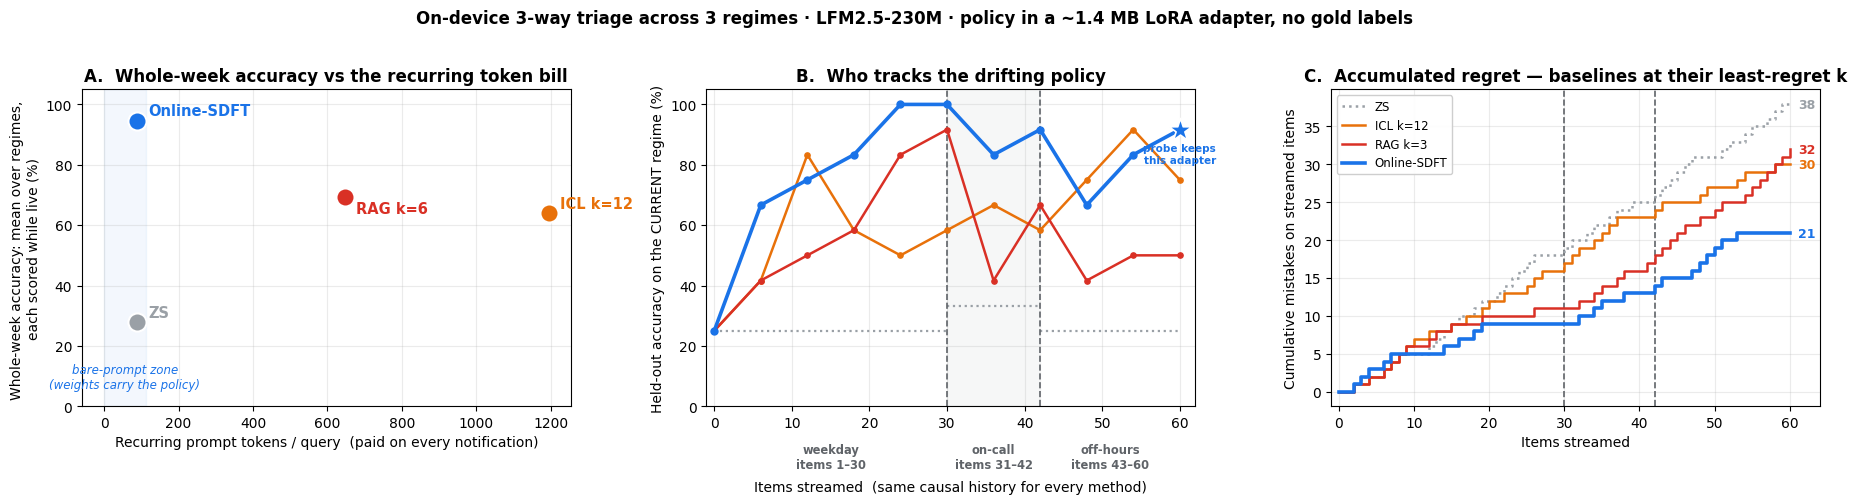

In [8]:
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
colors = {"ZS": "#9aa0a6", "ICL": "#e8710a", "RAG": "#d93025", "Online-SDFT": "#1a73e8"}
def col(n):
    for k, c in colors.items():
        if n.startswith(k):
            return c
    return "#5f6368"
zs_tok = arms["ZS"]["tok"]
bounds = [0, *DRIFTS, STREAM_LEN]
fig, (axA, axB, axC) = plt.subplots(1, 3, figsize=(18.4, 4.9))

# A — whole-week accuracy (each regime while live) vs the recurring token bill
for n, d in arms.items():
    axA.scatter(
        d["tok"], d["mean_live"] * 100, s=170, color=col(n), zorder=3,
        edgecolor="white", linewidth=1.5)
    axA.annotate(
        n, (d["tok"], d["mean_live"] * 100), textcoords="offset points",
        xytext=(8, -12 if n.startswith("RAG") else 4), fontsize=10.5,
        fontweight="bold", color=col(n))
axA.set_xlabel("Recurring prompt tokens / query  (paid on every notification)")
axA.set_ylabel(
    "Whole-week accuracy: mean over regimes, "
    "\neach scored while live (%)")
axA.set_ylim(0, 105)
axA.grid(alpha=.25)
axA.axvspan(0, zs_tok + 22, color="#1a73e8", alpha=.05)
axA.text(
    (zs_tok + 22) / 2, 6, "bare-prompt zone\n(weights carry the policy)",
    ha="center", fontsize=8.5, color="#1a73e8", style="italic")
axA.set_title("A.  Whole-week accuracy vs the recurring token bill", fontweight="bold")

# B — current-regime curves, every method from the same zero-shot start
for x in DRIFTS:
    axB.axvline(x, color="#5f6368", ls="--", lw=1.2)
for (s, e), p in zip(zip(bounds, bounds[1:]), (1, 2, 3)):
    axB.hlines(zs_by_phase[p] * 100, s, e, color=colors["ZS"], ls=":", lw=1.6, zorder=1)
for key, n in (("SDFT", "Online-SDFT"), ("ICL", f"ICL k={ICL_K}"), ("RAG", f"RAG k={RAG_K}")):
    axB.plot(
        curves["pos"], [v * 100 for v in curves[key]], "-o",
        color=colors["Online-SDFT" if key == "SDFT" else key],
        lw=2.6 if key == "SDFT" else 1.8, ms=5 if key == "SDFT" else 3.8,
        zorder=4 if key == "SDFT" else 3)
if best["pos"]:
    axB.scatter(
        [best["pos"]], [best["acc"] * 100], marker="*", s=300,
        color=colors["Online-SDFT"], edgecolor="white", linewidth=1.2, zorder=5)
    axB.annotate(
        "probe keeps\nthis adapter", (best["pos"], best["acc"] * 100),
        textcoords="offset points",
        xytext=(0, -24 if best["acc"] > 0.88 else 10), fontsize=7.5,
        color=colors["Online-SDFT"], ha="center", fontweight="bold")
tr = blended_transform_factory(axB.transData, axB.transAxes)
for idx, (s, e, r) in enumerate(zip(bounds, bounds[1:], REGIMES)):
    if idx % 2:
        axB.axvspan(s, e, color="#5f6368", alpha=.05, zorder=0)
    axB.text(
        (s + e) / 2, -0.115, f"{r}\nitems {s + 1}–{e}", transform=tr,
        ha="center", va="top", fontsize=8.3, color="#5f6368", fontweight="bold")
axB.set_xlim(-1, STREAM_LEN + 2)
axB.set_ylim(0, 105)
axB.grid(alpha=.25)
axB.set_xlabel("Items streamed  (same causal history for every method)", labelpad=36)
axB.set_ylabel("Held-out accuracy on the CURRENT regime (%)")
axB.set_title("B.  Who tracks the drifting policy", fontweight="bold")

# C — accumulated regret: cumulative mistakes on the streamed items
for x in DRIFTS:
    axC.axvline(x, color="#5f6368", ls="--", lw=1.2)
for key, n, ls in (
    ("ZS", "ZS", ":"),
    ("ICL", f"ICL k={ICL_K_REGRET}", "-"),
    ("RAG", f"RAG k={RAG_K_REGRET}", "-"),
    ("SDFT", "Online-SDFT", "-"),
):
    c = colors["Online-SDFT" if key == "SDFT" else key]
    axC.plot(
        regret["pos"], regret[key], ls, drawstyle="steps-post", color=c,
        lw=2.6 if key == "SDFT" else 1.8, label=n, zorder=4 if key == "SDFT" else 3)
    axC.annotate(
        str(regret[key][-1]), (STREAM_LEN, regret[key][-1]), textcoords="offset points",
        xytext=(6, -3), fontsize=9, color=c, fontweight="bold")
axC.set_xlim(-1, STREAM_LEN + 4)
axC.grid(alpha=.25)
axC.set_xlabel("Items streamed")
axC.set_ylabel("Cumulative mistakes on streamed items")
axC.set_title("C.  Accumulated regret — baselines at their least-regret k", fontweight="bold")
axC.legend(fontsize=8.5, loc="upper left", framealpha=.95)
fig.suptitle(
    "On-device 3-way triage across 3 regimes · LFM2.5-230M · policy in a ~1.4 MB LoRA adapter, no gold labels",
    fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()


## One item, four minds

An off-hours **social** push — off the clock it flips to **INTERRUPT** ("friends'
posts DO deserve a buzz on Saturday"), where the base model often files everything
as `LATER`. We pick the first such held-out item the served adapter gets right and
the frozen base does not.

**What to look for:** ZS/RAG wrong or token-heavy ICL right; Online-SDFT correct on
the bare prompt.


In [9]:
socials = [it for it in eval_cur if it["category"] == "social"]
# Batch ZS vs served-adapter over all socials (avoids nested per-item generate loops)
sdft_gens = generate(model, tok, socials, lambda x: build_msgs(x), bs=8)
with model.disable_adapter():
    zs_gens = generate(model, tok, socials, lambda x: build_msgs(x), bs=8)
pick = next(
    ((i, it) for i, (it, s, z) in enumerate(zip(socials, sdft_gens, zs_gens))
     if parse_action(s) == it["action"] and parse_action(z) != it["action"]),
    (0, socials[0]),
)
qi, q = pick
print("PROMPT:\n", q["prompt"])
print("\ncorrect (off-hours):", q["action"], "\n")
extra = arms[f"ICL k={ICL_K}"]["tok"] - arms["ZS"]["tok"]
# ICL / RAG use the frozen base; Online-SDFT / ZS reuse the batched replies above
with model.disable_adapter():
    icl_g = generate(model, tok, [q], lambda x: build_msgs(x, recent_demos(stream, ICL_K)), bs=1)[0]
    rag_g = generate(model, tok, [q], lambda x: build_msgs(x, retrieve(q, RAG_K)), bs=1)[0]
print(f"  {'ZS':12s} -> {parse_action(zs_gens[qi])}")
print(f"  {f'ICL k={ICL_K}':12s} -> {parse_action(icl_g)}   (+{extra:.0f} tokens every call)")
print(f"  {f'RAG k={RAG_K}':12s} -> {parse_action(rag_g)}")
print(f"  {'Online-SDFT':12s} -> {parse_action(sdft_gens[qi])}   (bare prompt)")


PROMPT:
 Triage this inbox item into one of INTERRUPT (buzz the user now), LATER (hold it for the digest), or ARCHIVE (never surface it). Answer with exactly one of INTERRUPT, LATER, or ARCHIVE.

Subject: 5 people liked your post
Tap to see the activity. 

correct (off-hours): INTERRUPT 

  ZS          -> LATER
  ICL k=12     -> INTERRUPT   (+1104 tokens every call)
  RAG k=6     -> ARCHIVE
  Online-SDFT -> INTERRUPT   (bare prompt)


## What to try next

1. **Change the policy (or make regimes longer)** — edit
   [`triage_common.py`](https://github.com/lin826/Online-SDFT-Demo/blob/main/triage_common.py)
   (`POLICY` / phase specs), re-run `run_baselines.py` to re-export
   `data/inbox_triage.json`, and point `DATA_URL` at your fork.
2. **Noisier feedback** — flip a fraction of observed actions before training, then
   watch the guardrail earn its keep.
3. **Re-run the k sweep locally** — `run_baselines.py` sweeps *k* ∈ {3, 6, 9, 12}
   (widen it). On Colab, try other `ICL_K` / `RAG_K` values. Does RAG ever stop
   serving stale weekday answers?
4. **Bigger model** — swap `MODEL_NAME` to `LiquidAI/LFM2.5-1.2B-Instruct`. 3-way
   routing is much steadier with more capacity (needs more VRAM / a longer runtime).
5. **Full toolkit** — [Local-SDFT](https://github.com/lin826/Local-SDFT): the
   `sdft.online` serve-while-learning package (probe guardrail + auto-rollback),
   the `/data` live chat loop, and GRPO.

3-way on a 230M is at the edge — that's the fun. Curiosity, not VRAM, is the bottleneck.
